In [49]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

In [46]:
def bs_delta(S, K, T_rem, r, vol):
    if T_rem <= 1e-6:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * vol**2) * T_rem) / (vol * np.sqrt(T_rem))
    return si.norm.cdf(d1)


def bs_price(S, K, T_rem, r, vol):
    if T_rem <= 1e-6:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * vol**2) * T_rem) / (vol * np.sqrt(T_rem))
    d2 = d1 - vol * np.sqrt(T_rem)
    return S * si.norm.cdf(d1) - K * np.exp(-r * T_rem) * si.norm.cdf(d2)

In [50]:
S0 = 100.0
K = 100.0
T = 1.0
r = 0.05
vol = 0.20
mu = 0.15

eu_call = bs_price(S0,K,r,T,vol)
print("Price of ATM EU Call is : ", eu_call)

Price of ATM EU Call is :  5.165791120894568


In [54]:
N_sim_steps = 100_000  
dt_sim = T / N_sim_steps
t_sim = np.linspace(0, T, N_sim_steps)


Z = np.random.randn(N_sim_steps)
Z[0] = 0.0
W = np.cumsum(Z) * np.sqrt(dt_sim)
S_market = S0 * np.exp((mu - 0.5 * vol**2) * t_sim + vol * W)

In [56]:
hedge_frequency = 4
hedge_interval = int(N_sim_steps * 1/hedge_frequency)
hedge_indices = list(range(0, N_sim_steps, hedge_interval))
if hedge_indices[-1] != N_sim_steps - 1:
    hedge_indices.append(N_sim_steps - 1) 


V0 = bs_price(S0, K, T, r, vol)
stock_qty = bs_delta(S0, K, T, r, vol)
cash = V0 - stock_qty * S0


portfolio_path = np.zeros(N_sim_steps)
portfolio_path[0] = V0

last_hedge_idx = 0

for i in range(1, N_sim_steps):
    dt_step = t_sim[i] - t_sim[i-1]
    cash *= np.exp(r * dt_step)
    
    portfolio_path[i] = stock_qty * S_market[i] + cash
    
    if i in hedge_indices and i < N_sim_steps - 1:
        tau = T - t_sim[i]
        new_delta = bs_delta(S_market[i], K, tau, r, vol)
        
        cash -= (new_delta - stock_qty) * S_market[i]
        stock_qty = new_delta
        last_hedge_idx = i


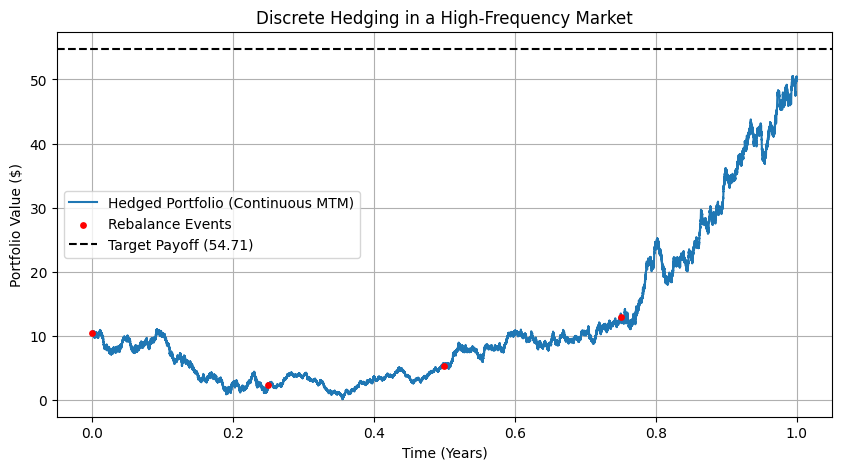

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(t_sim, portfolio_path, label='Hedged Portfolio (Continuous MTM)')

# Mark the discrete hedging points
plt.scatter(t_sim[hedge_indices[:-1]], portfolio_path[hedge_indices[:-1]], 
            color='red', s=15, zorder=5, label='Rebalance Events')

final_payoff = max(S_market[-1] - K, 0.0)
plt.axhline(final_payoff, color='black', linestyle='--', label=f'Target Payoff ({final_payoff:.2f})')

plt.title("Discrete Hedging in a High-Frequency Market")
plt.xlabel("Time (Years)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()